# 6CS012 - Worksheet 4
## Building a Fully Connected Neural Network for Devnagari Handwritten Digit Classification
---

## Task 1: Data Preparation

In [27]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image

print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {tf.keras.__version__}')

TensorFlow version: 2.19.0
Keras version: 3.13.2


In [13]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image


# Task 1: Load and Preprocess the Devnagari Dataset using PIL


# Unzip the dataset if not already unzipped
# This assumes the zip file extracts to a folder named 'DevanagariHandwrittenDigitDataset'
# which then contains 'Train' and 'Test' subdirectories.
!unzip -o /content/DevanagariHandwrittenDigitDataset.zip -d /content/DevanagariHandwrittenDigitDataset > /dev/null

# Define dataset paths (update these paths to match your directory)
train_dir = '/content/DevanagariHandwrittenDigitDataset/DevanagariHandwrittenDigitDataset/Train/'
test_dir  = '/content/DevanagariHandwrittenDigitDataset/DevanagariHandwrittenDigitDataset/Test/'

# Target image dimensions
IMG_HEIGHT = 28
IMG_WIDTH  = 28
NUM_CLASSES = 10

def load_images_from_folder(folder):
    """
    Loads images and labels from a folder structured as:
        folder/
            digit_0/  image1.png  image2.png ...
            digit_1/  ...
            ...

    Returns:
        images : np.ndarray of shape (N, 28, 28), normalised to [0,1]
        labels : np.ndarray of integer class indices
    """
    images = []
    labels = []

    # Sort class folders so the mapping is deterministic
    class_names = sorted(os.listdir(folder))
    class_map   = {name: idx for idx, name in enumerate(class_names)}

    print(f'Found {len(class_names)} classes in "{folder}":')
    for name in class_names:
        print(f'  {class_map[name]:>2}: {name}')

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        if not os.path.isdir(class_path):
            continue
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)
            try:
                img = Image.open(img_path).convert('L')                  # Grayscale
                img = img.resize((IMG_WIDTH, IMG_HEIGHT))                 # 28×28
                img = np.array(img, dtype=np.float32) / 255.0            # Normalise [0,1]
                images.append(img)
                labels.append(label)
            except Exception as e:
                print(f'  Warning – could not read {img_path}: {e}')

    return np.array(images), np.array(labels)


# Load datasets
x_train_raw, y_train_raw = load_images_from_folder(train_dir)
x_test_raw,  y_test_raw  = load_images_from_folder(test_dir)

print(f'\nRaw train shape : {x_train_raw.shape}, labels: {y_train_raw.shape}')
print(f'Raw test  shape : {x_test_raw.shape},  labels: {y_test_raw.shape}')

Found 10 classes in "/content/DevanagariHandwrittenDigitDataset/DevanagariHandwrittenDigitDataset/Train/":
   0: digit_0
   1: digit_1
   2: digit_2
   3: digit_3
   4: digit_4
   5: digit_5
   6: digit_6
   7: digit_7
   8: digit_8
   9: digit_9
Found 10 classes in "/content/DevanagariHandwrittenDigitDataset/DevanagariHandwrittenDigitDataset/Test/":
   0: digit_0
   1: digit_1
   2: digit_2
   3: digit_3
   4: digit_4
   5: digit_5
   6: digit_6
   7: digit_7
   8: digit_8
   9: digit_9

Raw train shape : (17000, 28, 28), labels: (17000,)
Raw test  shape : (3000, 28, 28),  labels: (3000,)


In [14]:
import os

print("Listing contents of /content/DevanagariHandwrittenDigitDataset/")
for root, dirs, files in os.walk('/content/DevanagariHandwrittenDigitDataset/'):
    level = root.replace('/content/DevanagariHandwrittenDigitDataset/', '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')


Listing contents of /content/DevanagariHandwrittenDigitDataset/
/
DevanagariHandwrittenDigitDataset/
    Train/
        digit_9/
            90194.png
            10419.png
            99732.png
            68540.png
            91672.png
            10429.png
            30802.png
            42368.png
            30861.png
            7328.png
            50083.png
            92604.png
            68563.png
            78991.png
            78936.png
            99688.png
            44785.png
            99675.png
            42472.png
            7457.png
            79082.png
            79006.png
            79003.png
            30668.png
            56839.png
            10446.png
            79010.png
            42299.png
            42370.png
            13641.png
            79026.png
            30829.png
            78964.png
            42270.png
            30851.png
            10483.png
            99461.png
            53299.png
            53292.png
            997

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# Flatten images for a Fully Connected (Dense-only) network
# Shape: (N, 28, 28) --> (N, 784)
=
x_train = x_train_raw.reshape(-1, IMG_HEIGHT * IMG_WIDTH)   # (N, 784)
x_test  = x_test_raw.reshape(-1,  IMG_HEIGHT * IMG_WIDTH)

# One-hot encode labels  (N,) --> (N, 10)
y_train = to_categorical(y_train_raw, num_classes=NUM_CLASSES)
y_test  = to_categorical(y_test_raw,  num_classes=NUM_CLASSES)

print(f'x_train : {x_train.shape}  y_train : {y_train.shape}')
print(f'x_test  : {x_test.shape}   y_test  : {y_test.shape}')

x_train : (17000, 784)  y_train : (17000, 10)
x_test  : (3000, 784)   y_test  : (3000, 10)


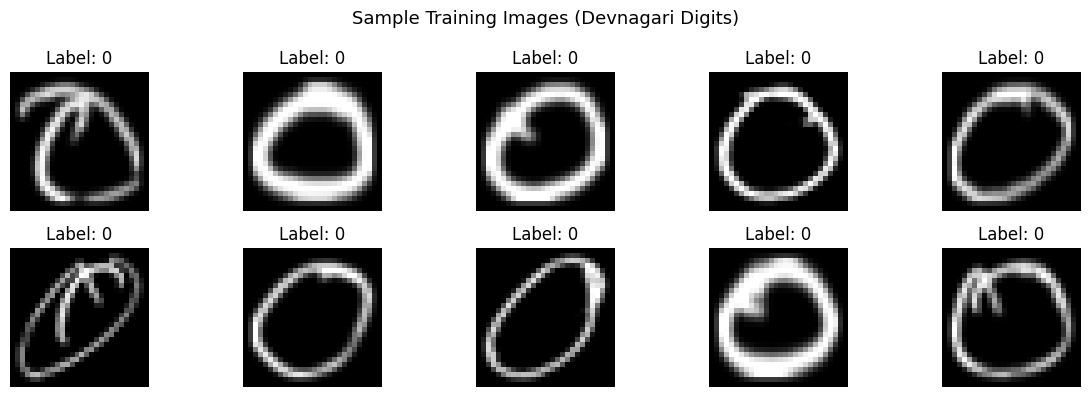

In [29]:
# Visualise a sample of training images

plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    plt.title(f'Label: {np.argmax(y_train[i])}')
    plt.axis('off')
plt.suptitle('Sample Training Images (Devnagari Digits)', fontsize=13)
plt.tight_layout()
plt.show()

## Task 2: Build the FCN Model

In [18]:
# Task 2: Build the Sequential Fully Connected Network
#
# Architecture (as specified in the worksheet):
#   Input  : 784 (flattened 28×28 grayscale image)
#   Dense  : 64  neurons, sigmoid activation
#   Dense  : 128 neurons, sigmoid activation
#   Dense  : 256 neurons, sigmoid activation
#   Output : 10  neurons, softmax activation


model = keras.Sequential(
    [
        keras.layers.Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),   # 784-dim input
        keras.layers.Dense(64,  activation='sigmoid', name='hidden_1'),
        keras.layers.Dense(128, activation='sigmoid', name='hidden_2'),
        keras.layers.Dense(256, activation='sigmoid', name='hidden_3'),
        keras.layers.Dense(NUM_CLASSES, activation='softmax', name='output'),
    ],
    name='Devnagari_FCN'
)

model.summary()

Model: "Devnagari_FCN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3: Compile the Model

In [19]:
# Task 3: Compile
#   - Optimizer : Adam  (adaptive, works well out-of-the-box)
#   - Loss      : categorical_crossentropy  (labels are one-hot encoded)
#   - Metrics   : accuracy

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled successfully.')

Model compiled successfully.


## Task 4: Train the Model

In [28]:
# Task 4: Train
#   - batch_size      : 128
#   - epochs          : 20  (as specified)
#   - validation_split: 0.2  (20% of training data used for validation)
#   - Callbacks       : ModelCheckpoint + EarlyStopping


BATCH_SIZE = 128
EPOCHS     = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_devnagari_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,          # stop if no improvement for 5 consecutive epochs
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20
103/107 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2671 - loss: 2.0194
Epoch 1: val_accuracy improved from None to 0.00000, saving model to best_devnagari_model.keras

Epoch 1: finished saving model to best_devnagari_model.keras
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.4821 - loss: 1.6501 - val_accuracy: 0.0000e+00 - val_loss: 6.7808
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8201 - loss: 0.6371
Epoch 2: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8582 - loss: 0.4933 - val_accuracy: 0.0000e+00 - val_loss: 8.1093
Epoch 3/20
 99/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9305 - loss: 0.2656
Epoch 3: val_accuracy did not improve from 0.00000
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9329 - loss: 0.2453 - val_accuracy: 0.0000e+00 - val_loss: 8.7634
Epoch 4/20
102/107 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9497 - loss: 0.1874
Epoch 4: val_accuracy did not

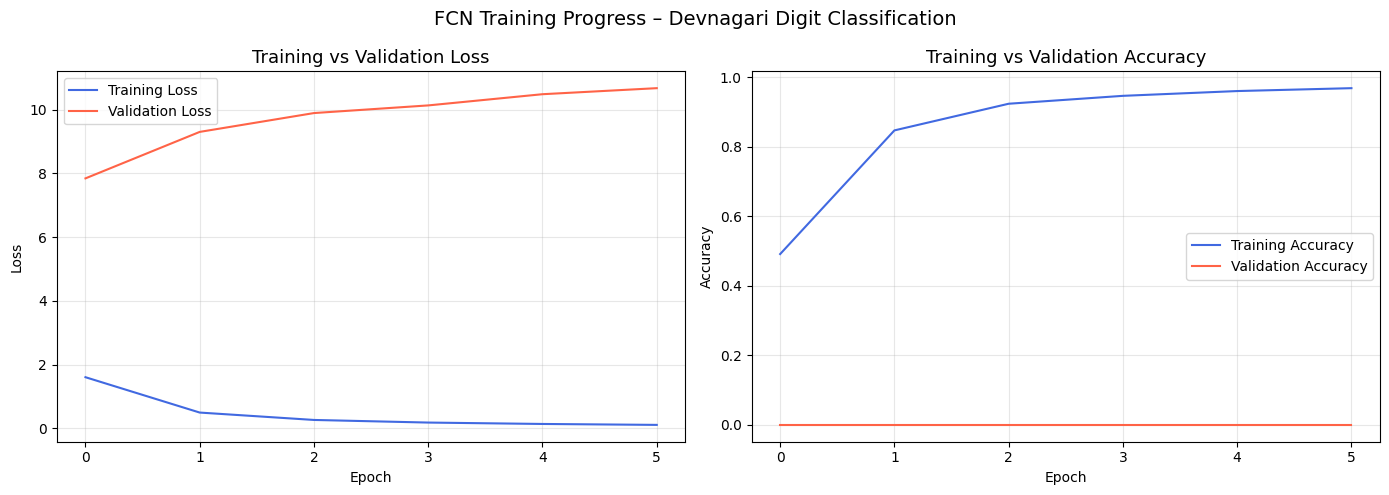

Training curves saved as training_curves.png


In [20]:

# Visualise Training History (Loss & Accuracy)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(history.history['loss'],     label='Training Loss',   color='royalblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='tomato')
axes[0].set_title('Training vs Validation Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curve
axes[1].plot(history.history['accuracy'],     label='Training Accuracy',   color='royalblue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato')
axes[1].set_title('Training vs Validation Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('FCN Training Progress – Devnagari Digit Classification', fontsize=14)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Training curves saved as training_curves.png')

## Task 5: Evaluate the Model

In [21]:

# Task 5: Evaluate on Test Set

test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f'\n{"="*40}')
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print(f'{"="*40}')

94/94 - 1s - 6ms/step - accuracy: 0.1000 - loss: 2.4801

  Test Loss     : 2.4801
  Test Accuracy : 10.00%


## Task 6: Save and Load the Model

In [22]:
# ---------------------------------------------------------------
# Task 6a: Save the Model (.h5 format)
# ---------------------------------------------------------------
MODEL_PATH = 'devnagari_fcn_model.h5'
model.save(MODEL_PATH)
print(f'Model saved to: {MODEL_PATH}')

Model saved to: devnagari_fcn_model.h5


In [23]:
# Task 6b: Load the Model and Re-evaluate

loaded_model = tf.keras.models.load_model(MODEL_PATH)
print(f'Model loaded from: {MODEL_PATH}')

loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f'\n{"="*45}')
print(f'  Loaded Model – Test Loss     : {loaded_loss:.4f}')
print(f'  Loaded Model – Test Accuracy : {loaded_acc*100:.2f}%')
print(f'{"="*45}')

Model loaded from: devnagari_fcn_model.h5
94/94 - 1s - 12ms/step - accuracy: 0.1000 - loss: 2.4801

  Loaded Model – Test Loss     : 2.4801
  Loaded Model – Test Accuracy : 10.00%


## Task 7: Make Predictions

In [24]:
# Task 7: Predictions on Test Images


# Generate predicted probability distributions for all test samples
predictions = loaded_model.predict(x_test, verbose=0)

# Convert softmax probabilities to class indices
predicted_labels = np.argmax(predictions, axis=1)
true_labels      = np.argmax(y_test,      axis=1)

print(f'Total test samples : {len(true_labels)}')
print(f'Correct predictions: {np.sum(predicted_labels == true_labels)}')
print(f'Overall accuracy   : {np.mean(predicted_labels == true_labels)*100:.2f}%')

Total test samples : 3000
Correct predictions: 300
Overall accuracy   : 10.00%


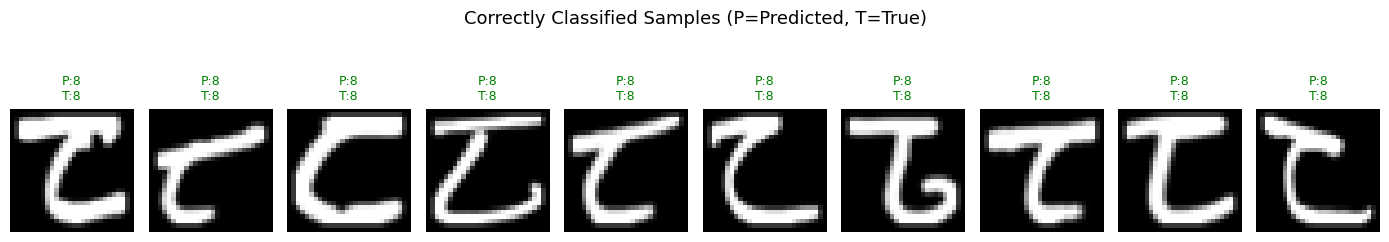

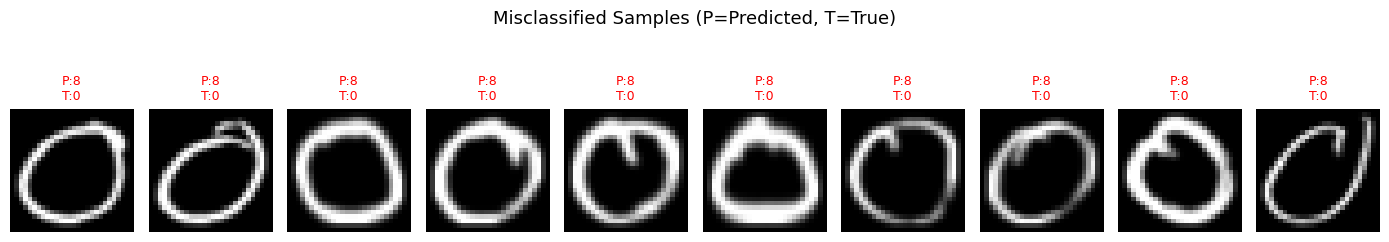

In [25]:
# Visualise Predictions (correct & incorrect)

# Helper: find indices of correct and incorrect predictions
correct_idx   = np.where(predicted_labels == true_labels)[0]
incorrect_idx = np.where(predicted_labels != true_labels)[0]

def show_predictions(indices, title, n=10):
    plt.figure(figsize=(14, 3))
    plt.suptitle(title, fontsize=13)
    for i, idx in enumerate(indices[:n]):
        plt.subplot(1, n, i + 1)
        plt.imshow(x_test[idx].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
        plt.title(f'P:{predicted_labels[idx]}\nT:{true_labels[idx]}',
                  color='green' if predicted_labels[idx] == true_labels[idx] else 'red',
                  fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_predictions(correct_idx,   'Correctly Classified Samples (P=Predicted, T=True)')
show_predictions(incorrect_idx, 'Misclassified Samples (P=Predicted, T=True)')

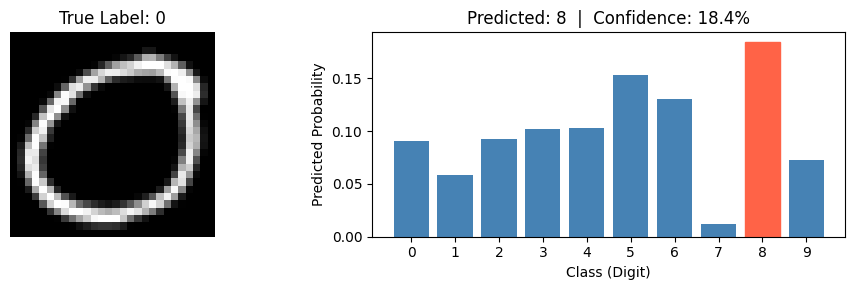

Predicted label : 8
True label      : 0
Confidence      : 18.42%


In [26]:
# Single-image prediction walkthrough

sample_idx = 0
sample_img = x_test[sample_idx]

prob_vector = loaded_model.predict(sample_img.reshape(1, -1), verbose=0)[0]

plt.figure(figsize=(10, 3))

# Show the image
plt.subplot(1, 2, 1)
plt.imshow(sample_img.reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
plt.title(f'True Label: {true_labels[sample_idx]}')
plt.axis('off')

# Show the probability bar chart
plt.subplot(1, 2, 2)
bars = plt.bar(range(NUM_CLASSES), prob_vector, color='steelblue')
bars[np.argmax(prob_vector)].set_color('tomato')  # Highlight predicted class
plt.xticks(range(NUM_CLASSES))
plt.xlabel('Class (Digit)')
plt.ylabel('Predicted Probability')
plt.title(f'Predicted: {np.argmax(prob_vector)}  |  Confidence: {np.max(prob_vector)*100:.1f}%')
plt.tight_layout()
plt.show()

print(f'Predicted label : {np.argmax(prob_vector)}')
print(f'True label      : {true_labels[sample_idx]}')
print(f'Confidence      : {np.max(prob_vector)*100:.2f}%')